# 인공지능(머신러닝)
## 지도학습: 문제, 정답을 알려주고 패턴 찾는 것
* 분류분석, 회귀분석
## 비지도학습: 문제만 알려주고 알고리즘이 알아서 패턴을 찾는 것
* 군집분석 

# 분류 분석의 대표적인 알고리즘 Tree 기반 모델
## 의사결정나무 (DecisionTree)
* Decision Tree는 데이터를 분할해서 조건문처럼 분기해 나가면서 예측하는 Tree 기반 모델
* 스무고개와 비슷하게 계속 질문을 던져서 분리
### 장점
* 직관적이고 해석 쉬움
* feature scaling(변수)이 필요 없음
* 범주형, 수치형 자료 모두를 분석할 수 있음(MinMax, StandardScaler 사용을 하지 않아도 됨)
* 범주형(DecisionTreeClassifier), 수치형(DecisionTreeRegressor) 자료 모두를 분석 할 수 있음
### 단점
* 과적합(overfitting)이 잘 일어남
* 최적의 트리를 찾기 어렵고, 시간이 오래 걸릴 수 있음

## 데이터 분석 과정
0. 필요한 라이브러리 로딩
1. 타이타닉 데이터 로딩
2. 데이터 전처리(결측값처리, 이상값 탐지)
3. EDA(탐색적 데이터 분석, 각 컬럼의 데이터 분포, 그래프로, 문자->숫자, 상관관계)
4. Feature Engineering (변수 선택, 새로운 특성 생성, 카테고리 변수의 더비 변수화 (one-hot encoding))
5. 최종 선택된 변수를 독립변수(X)와 종속변수(y)로 분리
6. sklearn의 train_test_split 불러와서 train과 test 세트로 분리
7. sklearn에서 DecisionTreeClassifier를 불러와서 모델 훈련
8. test 세트를 모델에 넣어서 예측값 생성(pred)
9. accuracy_score(), classification_report()를 이용해서 모델의 성능 확인

* 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

* 데이터 로딩

In [2]:
data = pd.read_csv('./data/Taitanic_train.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
# Age, Cabin, Embarked에 결측값 존재
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# 평균이 중앙값보다 크면 이상하다 생각해보기
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* 결측값 확인

In [5]:
# Age, Embarked는 20% 이하, Cabin은 77%
data.isna().sum() / len(data)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [6]:
# Age 결측값은 평균으로 / Embarked 결측값은 최빈값으로
# Cabin은 폐기
data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Embarked'] = data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data.drop("Cabin", axis=1, inplace=True)

In [7]:
data.isna().sum() / len(data)*100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

* 이상값 탐지

<Axes: >

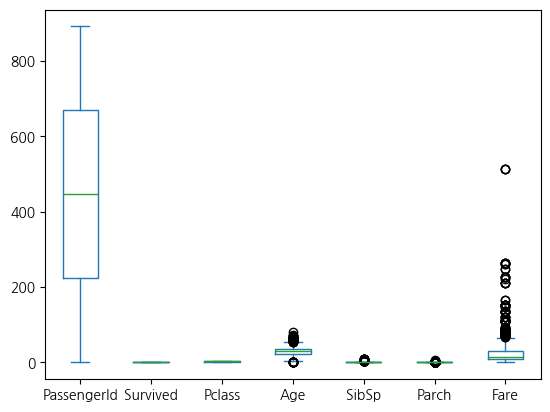

In [8]:
# box_plot으로 이상치 쉽게 확인
data.plot(kind='box')

In [9]:
# 이상치가 있는 SibSp부터 확인
data['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [10]:
data['SibSp'].value_counts()
# -> 딱히 이상하다고 보기 힘듦

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [11]:
# Age, Parch도 별로 이상함을 느끼긴 어려우나, Fare는 이상함
# 이상치 처리를 위해 describe 값 할당 후 IQR 구하는 방향으로 진행
fare_desc = data['Fare'].describe()

In [12]:
upper_bound = fare_desc['75%'] + (1.5*(fare_desc['75%'] - fare_desc['25%']))
lower_bound = fare_desc['75%'] - (1.5*(fare_desc['75%'] - fare_desc['25%']))

In [13]:
data.loc[data['Fare'] > upper_bound, 'Fare']

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64

In [14]:
# 선실 등급 별로 차이가 있는지 확인해본 결과 pclass가 1인 경우 가장 큰 값을 가짐
# 그 값을 더 심층적으로 파고들어봄
data['Fare'].max()

np.float64(512.3292)

In [15]:
data[data['Fare'] == 512.3292]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C


In [16]:
fare_desc_pclass = data[['Pclass', 'Fare']].groupby('Pclass').describe()

In [17]:
p1_upper_bound = fare_desc_pclass.loc[1,('Fare','75%')] + (1.5*(fare_desc_pclass.loc[1,('Fare','75%')]-fare_desc_pclass.loc[1,('Fare','25%')]))

In [18]:
p1_outlier = data[data['Fare'] >= p1_upper_bound]

In [19]:
# 왜 같은 가격이 4게나 있지 ? 예 대한 의문
p1_outlier['Fare'].value_counts()

Fare
263.0000    4
227.5250    4
211.3375    3
512.3292    3
262.3750    2
247.5208    2
211.5000    1
221.7792    1
Name: count, dtype: int64

EDA

<Axes: ylabel='count'>

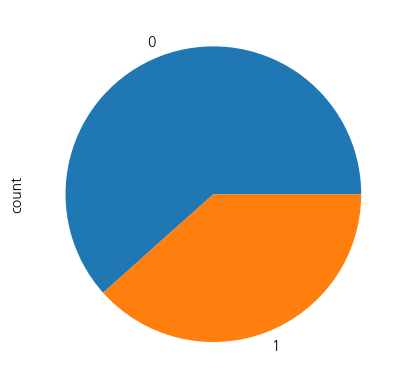

In [20]:
data['Survived'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

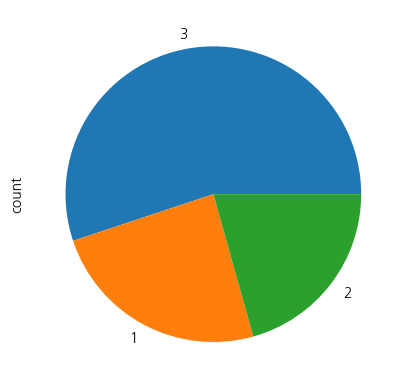

In [21]:
data['Pclass'].value_counts().plot(kind='pie')

<Axes: xlabel='Sex'>

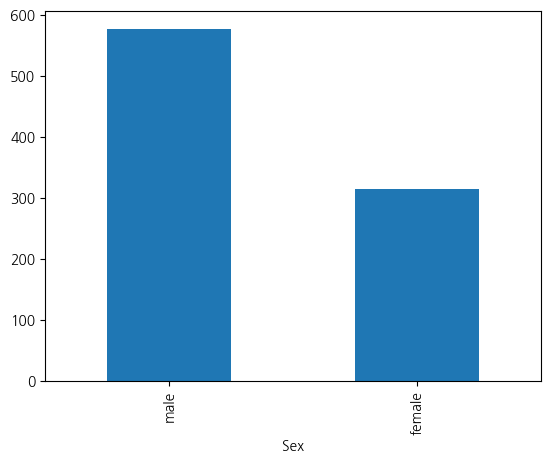

In [22]:
data['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

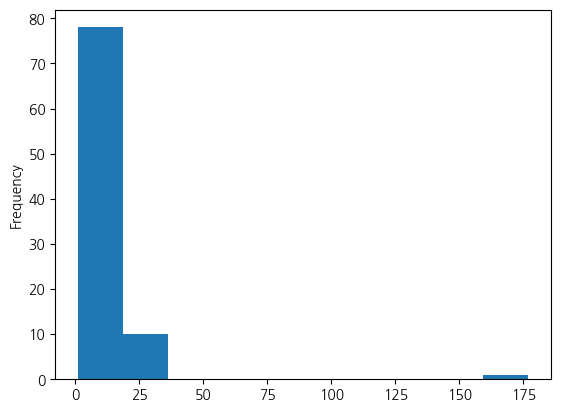

In [23]:
data['Age'].value_counts().plot(kind='hist')

In [24]:
data=data.drop(['PassengerId','Name','Ticket'], axis=1)

In [25]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


In [26]:
data[['Survived','SibSp']].groupby('SibSp').mean().sort_values(by='Survived',ascending=False)

,Survived
SibSp,
1,0.535885
2,0.464286
0,0.345395
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [27]:
data[['Survived','Parch']].groupby('Parch').mean().sort_values(by='Survived',ascending=False)

,Survived
Parch,
3,0.600000
1,0.550847
2,0.500000
0,0.343658
5,0.200000
4,0.000000
6,0.000000


In [28]:
data['Age'].value_counts()

Age
29.699118    177
24.000000     30
22.000000     27
18.000000     26
28.000000     25
            ... 
24.500000      1
0.670000       1
0.420000       1
34.500000      1
74.000000      1
Name: count, Length: 89, dtype: int64

In [29]:
data['Age'] = pd.cut(data['Age'],
       bins=[0,10,20,30,40,50,60,70,80,90],
       labels=['under10s','10','20','30','40','50','60','70','80']
      )

In [30]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,20,1,0,7.2500,S
1,1,1,female,30,1,0,71.2833,C
2,1,3,female,20,0,0,7.9250,S
3,1,1,female,30,1,0,53.1000,S
4,0,3,male,30,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,20,0,0,13.0000,S
887,1,1,female,10,0,0,30.0000,S
888,0,3,female,20,1,2,23.4500,S
889,1,1,male,20,0,0,30.0000,C


In [31]:
data['Family'] = data['SibSp'] + data['Parch']

In [32]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Family'],
      dtype='object')

In [33]:
data.drop(['SibSp','Parch'], axis=1)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,20,7.2500,S,1
1,1,1,female,30,71.2833,C,1
2,1,3,female,20,7.9250,S,0
3,1,1,female,30,53.1000,S,1
4,0,3,male,30,8.0500,S,0
...,...,...,...,...,...,...,...
886,0,2,male,20,13.0000,S,0
887,1,1,female,10,30.0000,S,0
888,0,3,female,20,23.4500,S,3
889,1,1,male,20,30.0000,C,0


In [34]:
data = pd.get_dummies(data, columns=['Sex','Age','Embarked','Family'], drop_first=True)

# 독립변수(X), 종속변수(y)

In [35]:
X = data.drop('Survived', axis=1)
y = data['Survived']

# 데이터를 훈련데이터와 테스트 데이터로 분할
# 홀드아웃

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=777)

# 분석 모델 선택 및 분석


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [40]:
dtc = DecisionTreeClassifier(random_state=777)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.7276119402985075
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       160
           1       0.68      0.61      0.64       108

    accuracy                           0.73       268
   macro avg       0.72      0.71      0.71       268
weighted avg       0.72      0.73      0.72       268

